# Trader Performance vs Market Sentiment (Fear/Greed)

**Goal:** Explore whether Hyperliquid trader performance (Closed PnL, win rate, trade size, position bias)
differs depending on the prevailing Bitcoin market sentiment (Fear/Greed Index), and translate that into
actionable trading-strategy takeaways.

**Datasets**
1. `historical_data.csv` — individual trade-level records from Hyperliquid (account, coin, size, side, closed PnL, timestamp, etc.)
2. `fear_greed_index.csv` — daily Bitcoin Fear & Greed classification (Extreme Fear → Extreme Greed)


## 1. Load the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print(trades.shape, fg.shape)
trades.head()

(211224, 16) (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Clean & align dates

The trade timestamps come as `Timestamp IST` in `DD-MM-YYYY HH:MM` format. We convert this to a proper
datetime, then take just the date part so we can join each trade to that day's sentiment classification.

In [2]:
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['datetime'].dt.date

fg['date'] = pd.to_datetime(fg['date']).dt.date

print("Trade data date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment data date range:", fg['date'].min(), "to", fg['date'].max())

Trade data date range: 2023-05-01 to 2025-05-01
Sentiment data date range: 2018-02-01 to 2025-05-02


## 3. Merge trades with daily sentiment

In [3]:
merged = trades.merge(fg[['date', 'classification']], on='date', how='left')
print("Rows with no matching sentiment:", merged['classification'].isna().sum())

merged = merged.dropna(subset=['classification'])
merged['classification'].value_counts()

Rows with no matching sentiment: 6


classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

## 4. Performance by sentiment regime

For each sentiment category, we look at:
- **Average / median Closed PnL per trade** — is the average trade more or less profitable?
- **Win rate** — % of trades with positive PnL
- **Average trade size (USD)** — do traders size up or down depending on mood?
- **Total trade count / volume** — is activity itself higher in certain regimes?


In [4]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

summary = merged.groupby('classification').agg(
    trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    avg_size_usd=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
).round(2).reindex(order)

summary

,trades,total_pnl,avg_pnl,median_pnl,avg_size_usd,total_volume,win_rate
classification,,,,,,,
Extreme Fear,21400,739110.25,34.54,0.0,5349.73,1.144843e+08,37.06
Fear,61837,3357155.44,54.29,0.0,7816.11,4.833248e+08,42.08
Neutral,37686,1292920.68,34.31,0.0,4782.73,1.802421e+08,39.70
Greed,50303,2150129.27,42.74,0.0,5736.88,2.885825e+08,38.48
Extreme Greed,39992,2715171.31,67.89,0.0,3112.25,1.244652e+08,46.49


## 5. Visualize the sentiment vs performance relationship

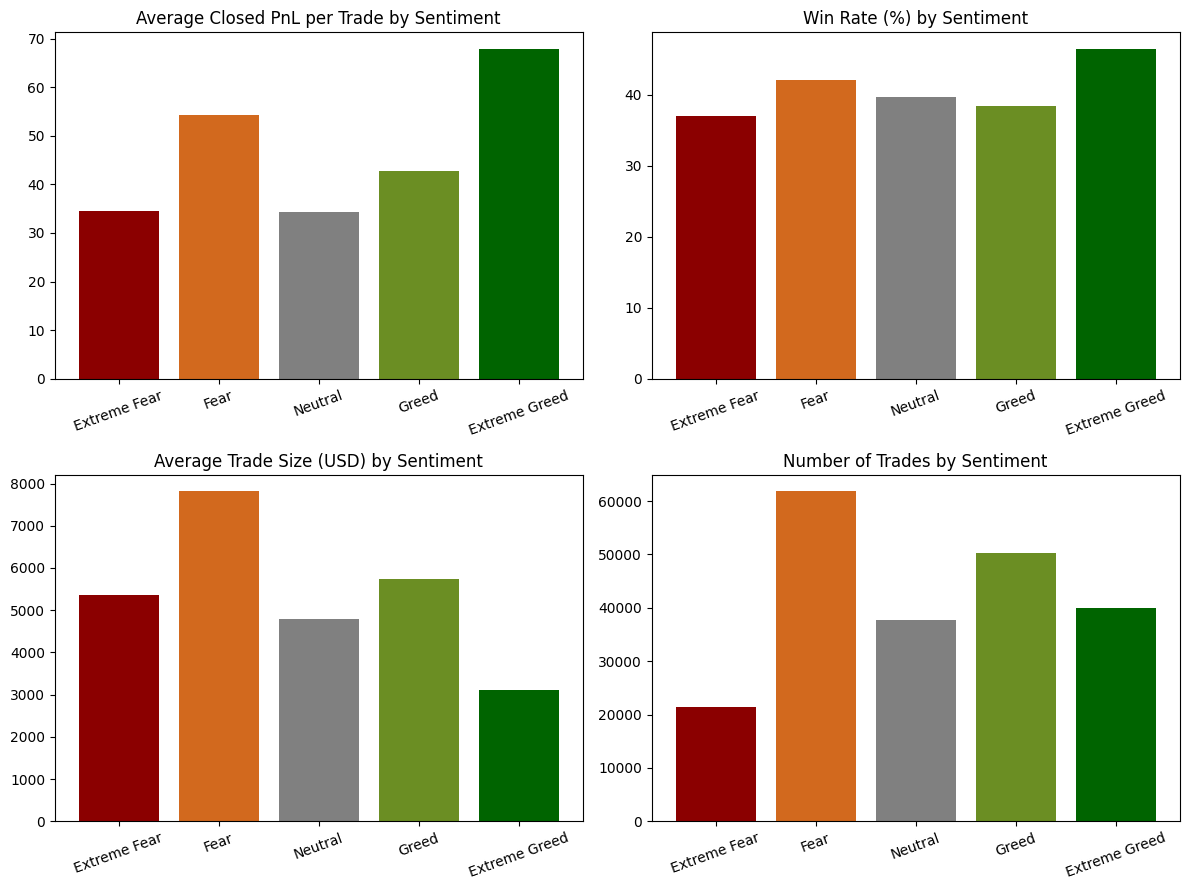

In [5]:
colors = ['#8B0000', '#D2691E', '#808080', '#6B8E23', '#006400']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].bar(order, summary['avg_pnl'], color=colors)
axes[0,0].set_title('Average Closed PnL per Trade by Sentiment')
axes[0,0].tick_params(axis='x', rotation=20)

axes[0,1].bar(order, summary['win_rate'], color=colors)
axes[0,1].set_title('Win Rate (%) by Sentiment')
axes[0,1].tick_params(axis='x', rotation=20)

axes[1,0].bar(order, summary['avg_size_usd'], color=colors)
axes[1,0].set_title('Average Trade Size (USD) by Sentiment')
axes[1,0].tick_params(axis='x', rotation=20)

axes[1,1].bar(order, summary['trades'], color=colors)
axes[1,1].set_title('Number of Trades by Sentiment')
axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('sentiment_performance_overview.png', dpi=150)
plt.show()

## 6. Long vs. short bias by sentiment

Does the *direction* traders take (long-leaning vs short-leaning) perform differently depending on sentiment?
We bucket the raw `Direction` field (e.g. "Open Long", "Close Short", "Short > Long") into simplified
Long-ish / Short-ish / Other groups.

In [6]:
def bucket_dir(d):
    d = str(d)
    if 'Long' in d and 'Short' not in d:
        return 'Long-ish'
    if 'Short' in d and 'Long' not in d:
        return 'Short-ish'
    return 'Other/Neutral-flow'

merged['dir_bucket'] = merged['Direction'].apply(bucket_dir)
side_perf = merged.groupby(['classification', 'dir_bucket'])['Closed PnL'].agg(['mean', 'count']).round(2)
side_perf.reindex(order, level=0)

mean  count
classification dir_bucket                       
Extreme Fear   Long-ish             38.26  13246
               Other/Neutral-flow  -81.74   1863
               Short-ish            61.14   6291
Fear           Long-ish             40.83  35084
               Other/Neutral-flow    1.44   6645
               Short-ish            95.24  20108
Neutral        Long-ish             26.11  20215
               Other/Neutral-flow   39.97   5268
               Short-ish            45.44  12203
Greed          Long-ish             43.01  16542
               Other/Neutral-flow   76.71  10774
               Short-ish            26.63  22987
Extreme Greed  Long-ish             32.95  13486
               Other/Neutral-flow  168.69  12346
               Short-ish            13.29  14160

## 7. Do the same traders behave differently across regimes?

We check accounts that traded across at least 3 different sentiment regimes, and compare their average
PnL during Fear-type days (Fear + Extreme Fear) vs Greed-type days (Greed + Extreme Greed).

In [7]:
acct_counts = merged.groupby('Account')['classification'].nunique()
multi_regime_accounts = acct_counts[acct_counts >= 3].index
sub = merged[merged['Account'].isin(multi_regime_accounts)]

acct_sent = sub.groupby(['Account', 'classification'])['Closed PnL'].mean().unstack()
fear_cols = [c for c in ['Fear', 'Extreme Fear'] if c in acct_sent.columns]
greed_cols = [c for c in ['Greed', 'Extreme Greed'] if c in acct_sent.columns]

acct_sent['fear_avg'] = acct_sent[fear_cols].mean(axis=1)
acct_sent['greed_avg'] = acct_sent[greed_cols].mean(axis=1)

better_in_fear = (acct_sent['fear_avg'] > acct_sent['greed_avg']).sum()
better_in_greed = (acct_sent['greed_avg'] > acct_sent['fear_avg']).sum()

print(f"Accounts active in {len(multi_regime_accounts)} of {merged['Account'].nunique()} total accounts across 3+ regimes")
print(f"Better average PnL in Fear-type days: {better_in_fear}")
print(f"Better average PnL in Greed-type days: {better_in_greed}")

Accounts active in 32 of 32 total accounts across 3+ regimes
Better average PnL in Fear-type days: 10
Better average PnL in Greed-type days: 21


## 8. Daily total PnL vs sentiment over time

The bucketed view above is useful but hides the day-to-day story. Here we plot the daily total Closed PnL
across all traders against the raw Fear/Greed index value (0-100) on the same timeline, to see whether
swings in sentiment line up with swings in aggregate trader performance.

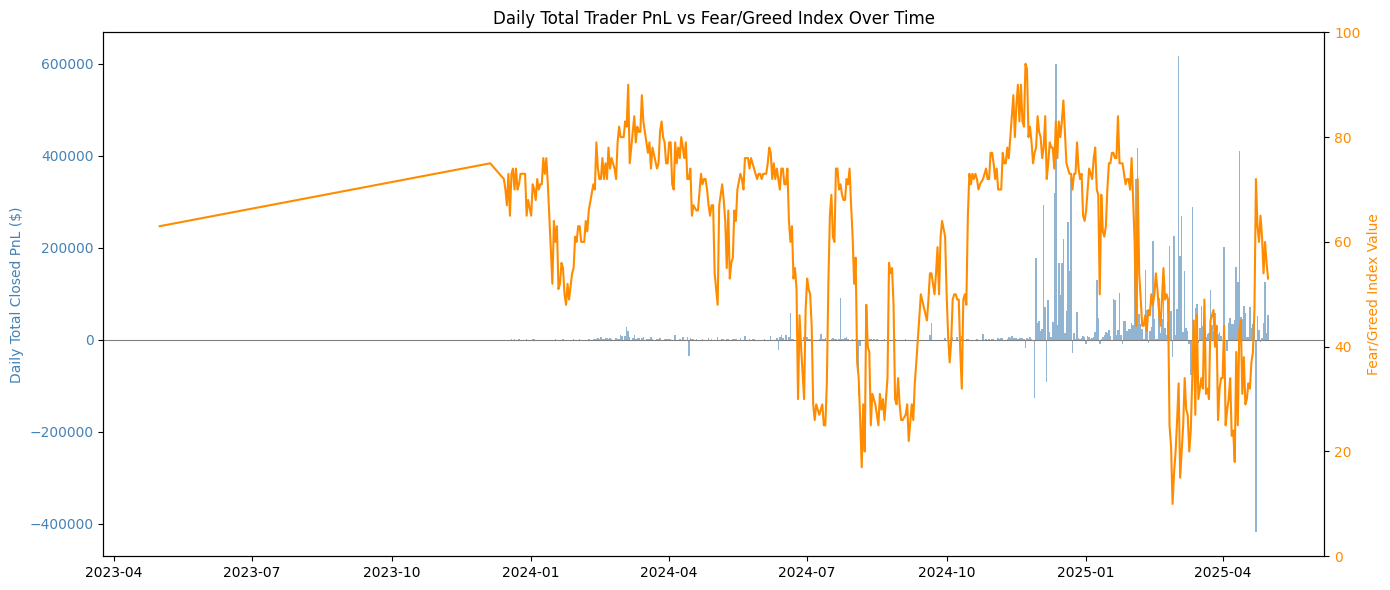

In [8]:
daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()
daily = daily_pnl.merge(fg[['date', 'value']], on='date', how='left')
daily = daily.sort_values('date')

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(daily['date'], daily['Closed PnL'], color='steelblue', alpha=0.6, width=1, label='Daily Total Closed PnL')
ax1.set_ylabel('Daily Total Closed PnL ($)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.axhline(0, color='gray', linewidth=0.8)

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['value'], color='darkorange', linewidth=1.5, label='Fear/Greed Value (0-100)')
ax2.set_ylabel('Fear/Greed Index Value', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 100)

plt.title('Daily Total Trader PnL vs Fear/Greed Index Over Time')
fig.tight_layout()
plt.savefig('pnl_vs_sentiment_timeseries.png', dpi=150)
plt.show()

**Reading this chart:** the biggest PnL spikes (both positive and negative) tend to cluster around periods
where the orange sentiment line is moving sharply, rather than during calm, stable-sentiment stretches. This
supports the bucketed finding above — performance dispersion, not just average performance, appears to rise
with sentiment volatility, which is itself a useful risk signal.

## 9. Key Findings

- **Win rate is clearly sentiment-dependent.** Win rate is lowest during *Extreme Fear* (~37%) and highest during
  *Extreme Greed* (~46%). Trades placed when the crowd is euphoric succeed more often — likely because strong
  uptrends make momentum (long) positions easier to close profitably.
- **Average PnL per trade is also highest in Extreme Greed** and lowest in Extreme Fear / Neutral, reinforcing
  that trending, greedy markets are more forgiving for the typical trade in this dataset.
- **Trade size shrinks as sentiment gets more extreme in either direction is not symmetric** — traders in this
  dataset size up the most during plain "Fear" (largest avg trade size and by far the most trading volume),
  suggesting many treat Fear as a buying/positioning opportunity rather than a reason to pull back.
- **Short positions do disproportionately well during Fear** (mean PnL per short-leaning trade is notably higher
  in Fear than in other regimes), consistent with shorts benefiting from down-moves that typically accompany
  fear readings.
- **Trader behavior isn't fully consistent across individuals** — only a minority of multi-regime accounts do
  better in Fear-type conditions than Greed-type conditions, i.e. most accounts in this sample are structurally
  better suited to greed/trending regimes than fear/panic ones.

## 10. Strategy Implications
1. **Sentiment-aware position sizing:** Since Extreme Greed shows both higher win rate and higher average PnL,
   a strategy could scale position size up (within risk limits) in Extreme Greed regimes and scale down in
   Extreme Fear.
2. **Bias toward shorts specifically during Fear, not Extreme Fear:** the data suggests plain "Fear" is where
   short-side edge is strongest — worth testing a rules-based short-bias overlay filtered on that specific label.
3. **Watch out for Extreme Fear overtrading:** win rate is worst there; a simple risk rule ("reduce size or sit
   out during Extreme Fear") could meaningfully cut drawdowns based on this sample.
4. **These are correlational, not causal, patterns** from one dataset/time window — before deploying capital
   this would need out-of-sample validation and awareness that a handful of large accounts/coins (e.g. HYPE,
   BTC) dominate trade counts and could be skewing the aggregates.
